# Retail Sales Data Analytic: Exploratory Data Analysis

## Project Overview

## Document Purpose

* Which countries generate the most revenue?
* Which products contribute most to revenue?
* What products have high quantity but low revenue?
* What products have low quantity but high revenue?
* Which products/countries account for 80% of revenue (Pareto analysis)?
* How many customers make repeat purchases?
* How long does it take customers to make another purchase?
* Which customer segments are the most valuable?
* Which customers are potential best customers?
* Which customers are at risk of being lost?

## Setup 

Before beginning the exploratory data analysis (EDA), we’ll load and prepare the cleaned dataset for analysis and visualization.

In [26]:
# modules we'll use
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# set thing font
plt.rcParams['font.monospace'] = ['DejaVu Sans']

# set project root
project_root = os.getcwd()
if os.path.basename(project_root) == "noteboook":
    project_root = os.path.dirname(project_root)

file_path = os.path.join(project_root, "data", "cleaned", "cleaned_retail_sales.xlsx")

try:
    df = pd.read_excel(file_path)
except ImportError as error:
    raise ImportError("Install openpyxl first: pip install openpyxl") from error

# set seed for reproducibility
np.random.seed(0)

# preview 10 rows of cleaned dataset
df.head(10)

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


## 1. Which countries generate the most revenue?


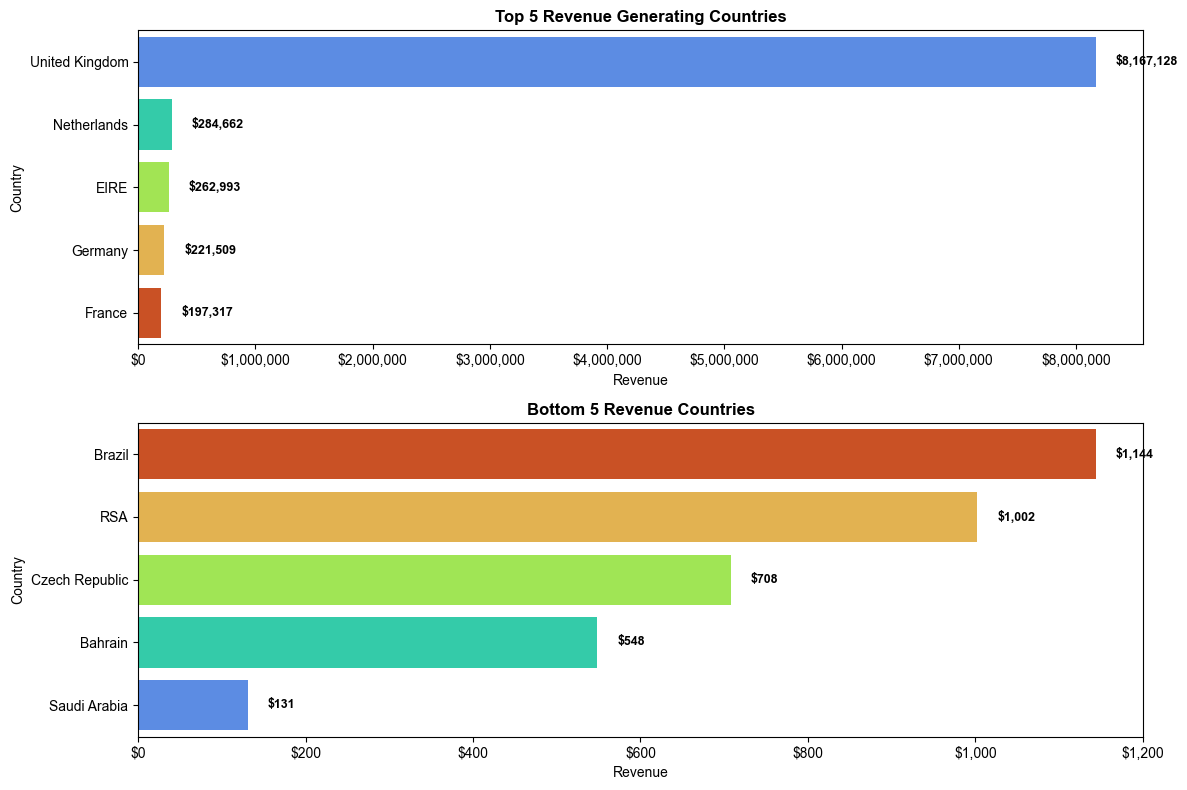

In [94]:
# caluculate total revenue
df["total_revenue"] = df['quantity'] * df['unit_price'] 
top_5_countries = df.groupby('country')['total_revenue'].sum().sort_values(ascending=False).head(5).reset_index()
buttom_5_countries = df.groupby('country')['total_revenue'].sum().sort_values(ascending=False).tail(5).reset_index()

# set up the 2-row grid layout
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# top 5
sns.barplot(
    data=top_5_countries,
    x='total_revenue',
    y='country',
    hue='country',  
    palette='turbo',
    legend=False,
    ax=axes[0]
)

axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
axes[0].set_title("Top 5 Revenue Generating Countries", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Revenue", fontsize=10, fontweight='light')
axes[0].set_ylabel("Country", fontsize=10, fontweight='light')

for patch, val in zip(axes[0].patches, top_5_countries['total_revenue']):
    if patch.get_width() > 0:  # Verify it is a valid bar object
        axes[0].text(
            patch.get_width() + (axes[0].get_xlim()[1] * 0.02),  
            patch.get_y() + patch.get_height() / 2,              
            f"${val:,.0f}",                                      
            ha='left', 
            va='center', 
            fontsize=9, 
            fontweight='semibold'
        )

# buttom 5
sns.barplot(
    data=buttom_5_countries,
    x='total_revenue',
    y='country',
    hue='country',  
    palette='turbo_r',
    legend=False,
    ax=axes[1]
)

axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
axes[1].set_title("Bottom 5 Revenue Countries", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Revenue", fontsize=10, fontweight='light')
axes[1].set_ylabel("Country", fontsize=10, fontweight='light')


for patch, val in zip(axes[1].patches, buttom_5_countries['total_revenue']):
    if patch.get_width() > 0: 
        axes[1].text(
            patch.get_width() + (axes[1].get_xlim()[1] * 0.02),  
            patch.get_y() + patch.get_height() / 2,              
            f"${val:,.0f}",                                      
            ha='left', 
            va='center', 
            fontsize=9, 
            fontweight='semibold'
        )

# Clean up layout spacing
plt.tight_layout()
plt.show()


## 2. Which products contribute most to revenue?

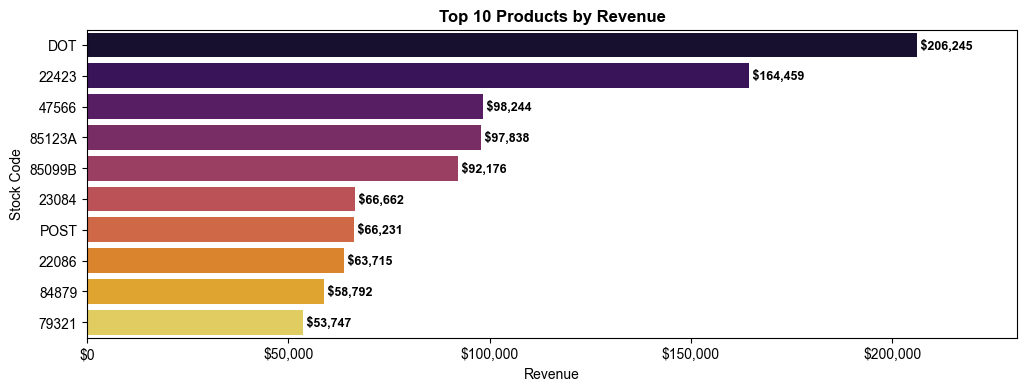

In [ ]:
df['total_revenue'] = pd.to_numeric(df['total_revenue'], errors='coerce')
df["stock_code"] = df["stock_code"].astype(str)

top_10_products = (
    df.groupby('stock_code').agg(
        total_revenue=('total_revenue', 'sum'),
        units_sold=('quantity', 'sum')
    )
    .sort_values('total_revenue', ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 4))

ax = sns.barplot(
    data=top_10_products,
    x='total_revenue',
    y='stock_code',
    hue='stock_code',
    palette='inferno',
    legend=False
)

# set ax format
ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter('${x:,.0f}')
)

# Add the ACTUAL revenue value to each bar
for patch, val in zip(
    ax.patches,
    top_10_products['total_revenue']
):
    ax.text(
        patch.get_width(),
        patch.get_y() + patch.get_height() / 2,
        f' ${val:,.0f}',
        ha='left',
        va='center',
        fontsize=9,
        fontweight='semibold'
    )

ax.margins(x=0.12)

ax.set_title('Top 10 Products by Revenue',fontsize=12,fontweight='bold')
ax.set_xlabel('Revenue', fontsize=10, fontweight='light')
ax.set_ylabel('Stock Code', fontsize=10, fontweight='light')

plt.show()
